In [ ]:
#code for conversion INLET_DIR = r"C:\Users\srite\Downloads\extractMe"
OUTPUT_H5 = "boundaryData_new.h5"

In [1]:
#!/usr/bin/env python3
"""
foam2h5_flat.py

Threaded + tqdm reader of constant/boundaryData/Inlet → single HDF5,
with flat structure:
  /data             Dataset (T, P, 3) containing U values across times
  /sampling_points  Dataset (P, 3)
  /sampling_times   Dataset (T,)
"""

import os
import re
import numpy as np
import h5py
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed

# === CONFIGURE THESE PATHS ===
INLET_DIR = r"C:\Users\srite\Downloads\extractMe"  # e.g., "/home/user/project/constant/boundaryData/Inlet"
OUTPUT_H5 = "boundaryData_new.h5"     # e.g., same folder, "boundaryData.h5"
# ============================

def parse_vector_field(fn):
    """
    Parse an OpenFOAM-style vector field file:
    - Finds '(' line, reads the integer count above it, then reads triplets until ')'.
    - Returns an (N,3) NumPy array.
    """
    lines = open(fn, 'r').read().splitlines()
    # find '('
    for j, L in enumerate(lines):
        if L.strip() == '(':
            start = j + 1
            break
    else:
        raise RuntimeError(f"No '(' in {fn}")
    # find count above it
    for k in range(start - 1, -1, -1):
        t = lines[k].strip()
        if re.fullmatch(r'\d+', t):
            count = int(t)
            break
    else:
        raise RuntimeError(f"No count above '(' in {fn}")
    vs = []
    for line in lines[start:]:
        s = line.strip()
        if s == ')':
            break
        tok = s.strip('()').split()
        if len(tok) != 3:
            raise RuntimeError(f"Bad vector line '{s}' in {fn}")
        vs.append([float(tok[0]), float(tok[1]), float(tok[2])])
    if len(vs) != count:
        raise RuntimeError(f"{fn}: expected {count}, got {len(vs)}")
    return np.array(vs, dtype=float)

def parse_points_file(fn):
    """Same format as vector field."""
    return parse_vector_field(fn)

def worker_read(idx_dname):
    """
    Read only U from one time directory.
    Returns (idx, U_array) where U_array is shape (P,3).
    """
    idx, dname = idx_dname
    base = os.path.join(INLET_DIR, dname)
    U_path = os.path.join(base, "U")
    U = parse_vector_field(U_path)
    return idx, U

def main():
    # 1) discover time folders
    entries = []
    for name in os.listdir(INLET_DIR):
        full = os.path.join(INLET_DIR, name)
        if not os.path.isdir(full):
            continue
        try:
            t = float(name)
        except ValueError:
            continue
        entries.append((t, name))
    if not entries:
        raise RuntimeError(f"No time dirs in '{INLET_DIR}'")
    entries.sort(key=lambda x: x[0])
    orig_times, dnames = zip(*entries)
    times = np.array(orig_times, dtype=float)
    # normalize so first time is zero
    times -= times[0]
    if not np.all(np.diff(times) > 0):
        raise RuntimeError("Times not ascending after shift")
    T = len(times)

    # 2) read points
    pts_fn = os.path.join(INLET_DIR, "points")
    if not os.path.isfile(pts_fn):
        raise RuntimeError(f"Points file not found: {pts_fn}")
    points = parse_points_file(pts_fn)  # shape (P,3)
    P = points.shape[0]

    # 3) sanity-check U count for first time
    sample = parse_vector_field(os.path.join(INLET_DIR, dnames[0], "U"))
    if sample.shape[0] != P:
        raise RuntimeError(f"points={P}, but U has {sample.shape[0]} rows in {dnames[0]}")

    # 4) allocate storage for U_data only
    U_data = np.empty((T, P, 3), dtype=float)

    # 5) threaded parse of U
    print(f"Reading {T} time folders with {os.cpu_count()} threads…")
    with ThreadPoolExecutor() as executor:
        futures = {executor.submit(worker_read, (i, dn)) for i, dn in enumerate(dnames)}
        for fut in tqdm(as_completed(futures), total=T, desc="parsing U"):
            idx, U = fut.result()
            U_data[idx] = U
    print("→ Read complete.")

    # DEBUG: print shapes
    print(f"After read: U_data.shape={U_data.shape}, points.shape={points.shape}, times.shape={times.shape}")

    # 6) write flat HDF5
    print(f"Writing '{OUTPUT_H5}'…")
    with h5py.File(OUTPUT_H5, "w") as hf:
        hf.create_dataset("data", data=U_data)
        hf.create_dataset("sampling_points", data=points)
        hf.create_dataset("sampling_times", data=times)
    print("→ Write complete.")

    # 7) re-open and inspect
    with h5py.File(OUTPUT_H5, "r") as hf:
        d_shape = hf["data"].shape
        p_shape = hf["sampling_points"].shape
        t_shape = hf["sampling_times"].shape
        print("Contents of HDF5:")
        print(f"  /data shape: {d_shape}  (T, P, 3)")
        print(f"  /sampling_points shape: {p_shape}  (P, 3)")
        print(f"  /sampling_times shape: {t_shape}  (T,)")

if __name__ == "__main__":
    main()


Reading 3226 time folders with 8 threads…


parsing U: 100%|██████████| 3226/3226 [04:42<00:00, 11.42it/s]  


→ Read complete.
After read: U_data.shape=(3226, 32761, 3), points.shape=(32761, 3), times.shape=(3226,)
Writing 'boundaryData_new.h5'…
→ Write complete.
Contents of HDF5:
  /data shape: (3226, 32761, 3)  (T, P, 3)
  /sampling_points shape: (32761, 3)  (P, 3)
  /sampling_times shape: (3226,)  (T,)


In [ ]:
#code for value genration

In [20]:
time_steps = [1, -1]
# read in hdf5 file
print(f"READING FILE {outputFilename}")
with h5py.File(outputFilename, "r") as hf:
    print(hf.keys())
    time = hf[dataset_name_time][()]
    points = hf[dataset_name_points][()]
    print(hf[dataset_name_data].shape)
    data = hf[dataset_name_data][time_steps,:,:]
print("-------------- TIME --------------")
print(time)
print(np.diff(time))
print(np.min(np.diff(time)))
print(np.max(np.diff(time)))
print(np.mean(np.diff(time)))
print("-------------- POINTS --------------")
print(points)
print("-------------- DATA --------------")
print(data)

READING FILE boundaryData.h5
<KeysViewHDF5 ['U', 'nuSgs', 'p']>
(3226, 32761, 3)
-------------- TIME --------------
[0.00000e+00 4.60000e-06 9.20000e-06 ... 1.37576e-02 1.37620e-02
 1.37665e-02]
[4.6e-06 4.6e-06 4.6e-06 ... 4.5e-06 4.4e-06 4.5e-06]
9.999999999994822e-08
5.5999999999997024e-06
4.268682170542635e-06
-------------- POINTS --------------
[[-3.8181476e-01  5.5143635e-02 -2.6024794e-02]
 [-3.8181476e-01  5.5130264e-02 -2.6024794e-02]
 [-3.8181476e-01  5.5115545e-02 -2.6024794e-02]
 ...
 [-3.8181476e-01 -3.7854369e-04 -2.5529709e-02]
 [-3.8181476e-01 -8.7912622e-04 -2.5529709e-02]
 [-3.8181476e-01 -1.3797087e-03 -2.5529709e-02]]
-------------- DATA --------------
[[[ 1.3540271e-01 -9.5028197e-05  1.7764976e-02]
  [ 4.1976555e-01 -6.1849759e-04  4.7277064e-02]
  [ 7.4019143e-01 -1.8081555e-03  7.4628609e-02]
  ...
  [ 1.9997588e+01 -5.7255030e-01 -4.6121283e-01]
  [ 2.0101051e+01 -9.2784339e-01 -2.9241655e-01]
  [ 2.0216891e+01 -1.3158668e+00 -1.5867924e-01]]

 [[ 3.1563879e-0

In [ ]:
#code for plotting

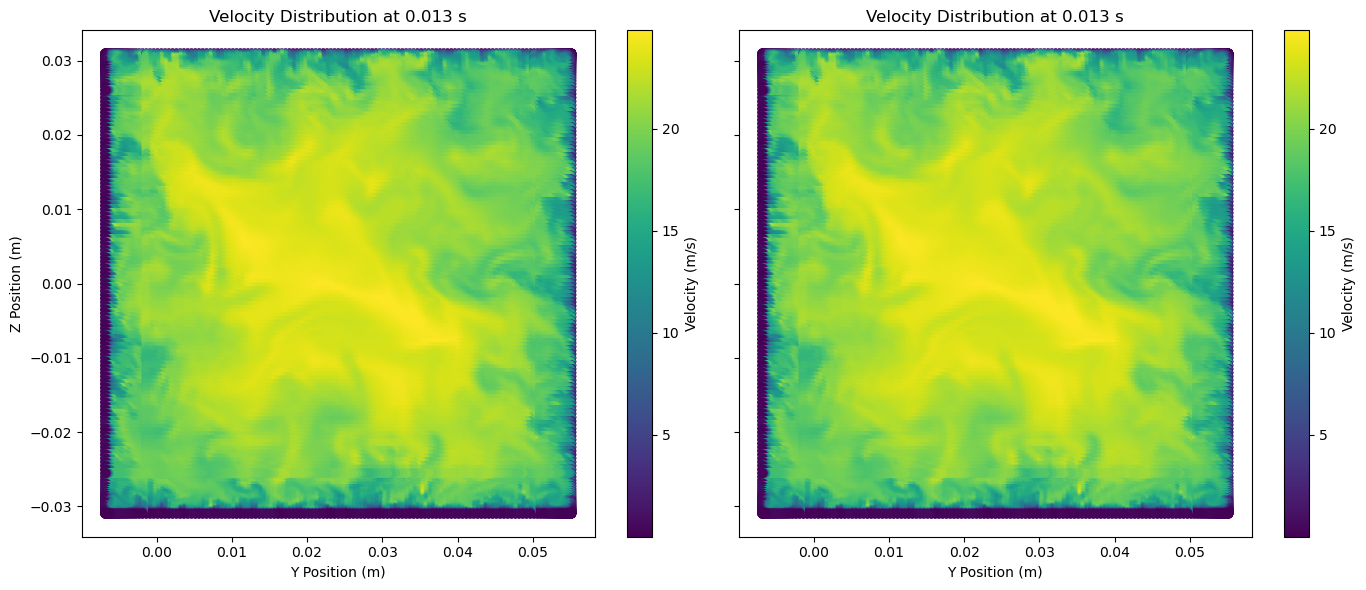

In [19]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

# Load the data
outputFilename = 'boundaryData.h5'
dataset_name_time = 'U/sampling_times'
dataset_name_points = 'U/sampling_points'
dataset_name_data = 'U/data'

# Desired time values
time_values = [0.013, 0.013]

# Read the data
with h5py.File(outputFilename, "r") as hf:
    time = hf[dataset_name_time][()]
    points = hf[dataset_name_points][()]
    data = hf[dataset_name_data][()]

# Find the indices corresponding to the specified time values
time_indices = [np.argmin(np.abs(time - t)) for t in time_values]

# Extract data for the selected timesteps
data_1 = data[time_indices[0], :, :]
data_2 = data[time_indices[1], :, :]

# Extract y and z coordinates and velocity magnitude
y_coords = points[:, 1]
z_coords = points[:, 2]
velocity_1 = np.linalg.norm(data_1, axis=1)
velocity_2 = np.linalg.norm(data_2, axis=1)

# Plotting
fig, axs = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# First plot
sc1 = axs[0].scatter(y_coords, z_coords, c=velocity_1, cmap='viridis')
axs[0].set_title(f'Velocity Distribution at {time_values[0]} s')
axs[0].set_xlabel('Y Position (m)')
axs[0].set_ylabel('Z Position (m)')
cbar1 = plt.colorbar(sc1, ax=axs[0])
cbar1.set_label('Velocity (m/s)')

# Second plot
sc2 = axs[1].scatter(y_coords, z_coords, c=velocity_2, cmap='viridis')
axs[1].set_title(f'Velocity Distribution at {time_values[1]} s')
axs[1].set_xlabel('Y Position (m)')
cbar2 = plt.colorbar(sc2, ax=axs[1])
cbar2.set_label('Velocity (m/s)')

plt.tight_layout()
plt.show()
